In [15]:
import re
import numpy as np
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, mean_squared_error

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

df = pd.read_csv("manchester_postpartum_triage_v1.csv")
texts = df['patient_message'].astype(str).tolist()
labels_orig = df['triage_level'].astype(int).tolist()

In [19]:
def tokenize(text):
    text = text.lower().replace("’", "'")
    return re.findall(r"\b\w+(?:'\w+)?\b", text)

all_words = []
for t in texts:
    all_words.extend(tokenize(t))

word_counts = Counter(all_words)
vocab = {word: i+2 for i, (word, _) in enumerate(word_counts.items())}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
VOCAB_SIZE = len(vocab)
MAX_LEN = 100  

def text_to_sequence(text, vocab, max_len):
    tokens = tokenize(text)
    seq = [vocab.get(token, 1) for token in tokens]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X_seq = [text_to_sequence(t, vocab, MAX_LEN) for t in texts]

#(60% Train, 15% Val, 25% Test)
X_train, X_temp, y_train_orig, y_temp = train_test_split(
    X_seq, labels_orig, test_size=0.40, random_state=42, stratify=labels_orig
)
X_val, X_test, y_val_orig, y_test_orig = train_test_split(
    X_temp, y_temp, test_size=0.625, random_state=42, stratify=y_temp
)

# lables
y_train_binary = [0.0 if x == 0 else 1.0 for x in y_train_orig]
y_val_binary = [0.0 if x == 0 else 1.0 for x in y_val_orig]
y_test_binary = [0.0 if x == 0 else 1.0 for x in y_test_orig]

# Dataset ו-DataLoader part 1
class LSTMRegressionDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32) # float32 עבור רגרסיה וסיגמואיד
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]
    def __len__(self):
        return len(self.labels)

train_loader_s1 = DataLoader(LSTMRegressionDataset(X_train, y_train_binary), batch_size=32, shuffle=True)
val_loader_s1 = DataLoader(LSTMRegressionDataset(X_val, y_val_binary), batch_size=32, shuffle=False)
test_loader_s1 = DataLoader(LSTMRegressionDataset(X_test, y_test_binary), batch_size=32, shuffle=False)

# 5.  (יוצא פלט בודד לטובת Sigmoid/MSE)
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1) 
        
    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        return self.fc(hidden_concat).squeeze(-1)

# part 1
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
model_stage1 = BiLSTMRegressor(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
criterion_s1 = nn.BCEWithLogitsLoss() # כולל סיגמואיד מובנה ומיוצב מתמטית
optimizer_s1 = optim.Adam(model_stage1.parameters(), lr=0.001)

# part 1 training
EPOCHS = 4
history_s1_train, history_s1_val = [], []
print("🚀 Starting Stage 1 Bi-LSTM Training (Binary Filter)...")

for epoch in range(EPOCHS):
    model_stage1.train()
    total_loss = 0
    for seqs, lbls in train_loader_s1:
        seqs, lbls = seqs.to(device), lbls.to(device)
        optimizer_s1.zero_grad()
        outputs = model_stage1(seqs)
        loss = criterion_s1(outputs, lbls)
        loss.backward()
        optimizer_s1.step()
        total_loss += loss.item()
        
    model_stage1.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for seqs, lbls in val_loader_s1:
            seqs, lbls = seqs.to(device), lbls.to(device)
            outputs = model_stage1(seqs)
            loss = criterion_s1(outputs, lbls)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            val_correct += (preds == lbls).sum().item()
            
    epoch_train_loss = total_loss / len(train_loader_s1)
    epoch_val_loss = val_loss / len(val_loader_s1)
    history_s1_train.append(epoch_train_loss)
    history_s1_val.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_correct/len(y_val_binary):.4f}")

🚀 Starting Stage 1 Bi-LSTM Training (Binary Filter)...
Epoch 1/4 | Train Loss: 0.5583 | Val Loss: 0.5218 | Val Acc: 0.7622
Epoch 2/4 | Train Loss: 0.3733 | Val Loss: 0.1745 | Val Acc: 0.9667
Epoch 3/4 | Train Loss: 0.1152 | Val Loss: 0.2322 | Val Acc: 0.9644
Epoch 4/4 | Train Loss: 0.0558 | Val Loss: 0.0938 | Val Acc: 0.9800


In [21]:
print("\n🛠️ Preparing Stage 2: Severity Regressor (Only Urgent Cases 1-3)...")

def filter_urgent_only_lstm(X_set, y_orig_set):
    X_filtered, y_filtered = [], []
    for seq, label in zip(X_set, y_orig_set):
        if label > 0:
            X_filtered.append(seq)
            y_filtered.append(float(label))
    return X_filtered, y_filtered

X_train_s2, y_train_s2 = filter_urgent_only_lstm(X_train, y_train_orig)
X_val_s2, y_val_s2 = filter_urgent_only_lstm(X_val, y_val_orig)

train_loader_s2 = DataLoader(LSTMRegressionDataset(X_train_s2, y_train_s2), batch_size=32, shuffle=True)
val_loader_s2 = DataLoader(LSTMRegressionDataset(X_val_s2, y_val_s2), batch_size=32, shuffle=False)

# model part 2
model_stage2 = BiLSTMRegressor(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
criterion_s2 = nn.MSELoss() # המדד המבוקש - Mean Squared Error
optimizer_s2 = optim.Adam(model_stage2.parameters(), lr=0.001)

history_s2_train, history_s2_val = [], []

for epoch in range(EPOCHS):
    model_stage2.train()
    total_loss = 0
    for seqs, lbls in train_loader_s2:
        seqs, lbls = seqs.to(device), lbls.to(device)
        optimizer_s2.zero_grad()
        outputs = model_stage2(seqs)
        loss = criterion_s2(outputs, lbls)
        loss.backward()
        optimizer_s2.step()
        total_loss += loss.item()
        
    model_stage2.eval()
    val_loss = 0
    with torch.no_grad():
        for seqs, lbls in val_loader_s2:
            seqs, lbls = seqs.to(device), lbls.to(device)
            outputs = model_stage2(seqs)
            loss = criterion_s2(outputs, lbls)
            val_loss += loss.item()
            
    epoch_train_loss = total_loss / len(train_loader_s2)
    epoch_val_loss = val_loss / len(val_loader_s2)
    history_s2_train.append(epoch_train_loss)
    history_s2_val.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train MSE Loss: {epoch_train_loss:.4f} | Val MSE Loss: {epoch_val_loss:.4f}")


🛠️ Preparing Stage 2: Severity Regressor (Only Urgent Cases 1-3)...
Epoch 1/4 | Train MSE Loss: 1.5006 | Val MSE Loss: 0.6696
Epoch 2/4 | Train MSE Loss: 0.5522 | Val MSE Loss: 0.3728
Epoch 3/4 | Train MSE Loss: 0.2043 | Val MSE Loss: 0.2157
Epoch 4/4 | Train MSE Loss: 0.1222 | Val MSE Loss: 0.1493



🏁 GENERATING EVALUATION METRICS FOR LSTM PIPELINE

🔹 STAGE 1 (Binary Filter - Routine vs Urgent):
   • Accuracy: 0.9813
   • Macro F1-Score: 0.9737

📋 Detailed Stage 1 Report:
              precision    recall  f1-score   support

 Routine (0)       0.99      0.93      0.96       179
  Urgent (1)       0.98      1.00      0.99       571

    accuracy                           0.98       750
   macro avg       0.99      0.96      0.97       750
weighted avg       0.98      0.98      0.98       750


🔹 STAGE 2 (Severity Regressor - Levels 1-3 Only):
   • Mean Squared Error (MSE): 0.1579
   • Accuracy (Rounded): 0.8074
   • Macro F1-Score (Rounded): 0.8070

📋 Detailed Stage 2 Report:
              precision    recall  f1-score   support

     Level 1       0.77      0.83      0.80       189
     Level 2       0.70      0.71      0.71       185
     Level 3       0.96      0.88      0.92       197

    accuracy                           0.81       571
   macro avg       0.81      0.81    

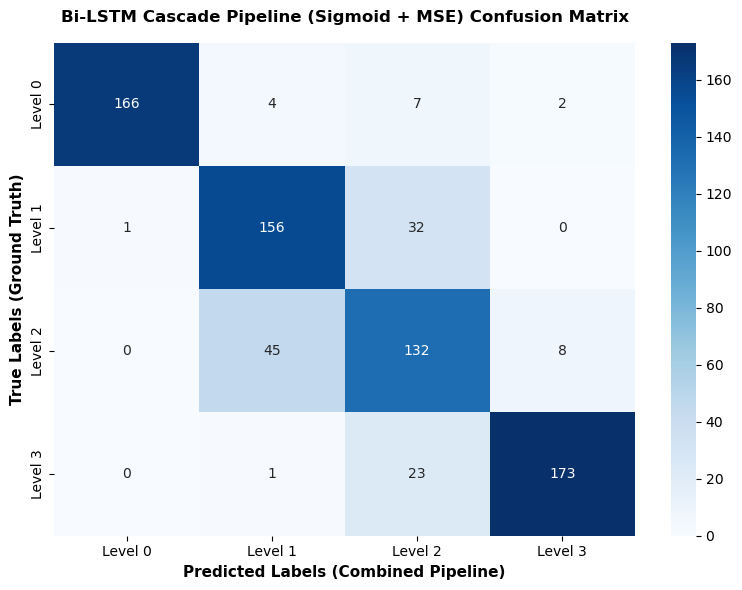

In [23]:
print("\n" + "="*50)
print("🏁 GENERATING EVALUATION METRICS FOR LSTM PIPELINE")
print("="*50)

model_stage1.eval()
model_stage2.eval()

# test set - part 1
s1_preds_list = []
test_loader_full_s1 = DataLoader(LSTMRegressionDataset(X_test, y_test_binary), batch_size=32, shuffle=False)

with torch.no_grad():
    for seqs, _ in test_loader_full_s1:
        seqs = seqs.to(device)
        outputs = model_stage1(seqs)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int().cpu().numpy()
        s1_preds_list.extend(preds)

print(f"\n🔹 STAGE 1 (Binary Filter - Routine vs Urgent):")
print(f"   • Accuracy: {accuracy_score(y_test_binary, s1_preds_list):.4f}")
print(f"   • Macro F1-Score: {f1_score(y_test_binary, s1_preds_list, average='macro'):.4f}")
print("\n📋 Detailed Stage 1 Report:")
print(classification_report(y_test_binary, s1_preds_list, target_names=["Routine (0)", "Urgent (1)"]))

# test set part 2
X_test_s2, y_test_s2_orig = filter_urgent_only_lstm(X_test, y_test_orig)
test_loader_s2_only = DataLoader(LSTMRegressionDataset(X_test_s2, y_test_s2_orig), batch_size=32, shuffle=False)

s2_only_continuous = []
with torch.no_grad():
    for seqs, _ in test_loader_s2_only:
        seqs = seqs.to(device)
        outputs = model_stage2(seqs)
        s2_only_continuous.extend(outputs.cpu().numpy())

s2_only_preds_rounded = np.clip(np.round(s2_only_continuous), 1.0, 3.0).astype(int)
y_test_s2_orig_int = np.array(y_test_s2_orig).astype(int)

print(f"\n🔹 STAGE 2 (Severity Regressor - Levels 1-3 Only):")
print(f"   • Mean Squared Error (MSE): {mean_squared_error(y_test_s2_orig_int, s2_only_continuous):.4f}")
print(f"   • Accuracy (Rounded): {accuracy_score(y_test_s2_orig_int, s2_only_preds_rounded):.4f}")
print(f"   • Macro F1-Score (Rounded): {f1_score(y_test_s2_orig_int, s2_only_preds_rounded, average='macro'):.4f}")
print("\n📋 Detailed Stage 2 Report:")
print(classification_report(y_test_s2_orig_int, s2_only_preds_rounded, target_names=["Level 1", "Level 2", "Level 3"]))

# pipeline
test_loader_full = DataLoader(LSTMRegressionDataset(X_test, y_test_orig), batch_size=32, shuffle=False)
s2_full_continuous = []
with torch.no_grad():
    for seqs, _ in test_loader_full:
        seqs = seqs.to(device)
        outputs = model_stage2(seqs)
        s2_full_continuous.extend(outputs.cpu().numpy())

final_pipeline_preds = []
for idx in range(len(X_test)):
    if s1_preds_list[idx] == 0:
        final_pipeline_preds.append(0)
    else:
        pred_scaled = np.clip(s2_full_continuous[idx], 1.0, 3.0)
        final_pipeline_preds.append(int(np.round(pred_scaled)))


print(f"\n👑 FINAL COMBINED CASCADE PIPELINE (Full Model 0-3):")
print(f"   • Global Accuracy: {accuracy_score(y_test_orig, final_pipeline_preds):.4f}")
print(f"   • Global Macro F1-Score: {f1_score(y_test_orig, final_pipeline_preds, average='macro'):.4f}")
print("\n📋 Final Full Pipeline Classification Report:")
print(classification_report(y_test_orig, final_pipeline_preds, target_names=["Level 0", "Level 1", "Level 2", "Level 3"]))

#matrix
cm_cascade = confusion_matrix(y_test_orig, final_pipeline_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cascade, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Level 0", "Level 1", "Level 2", "Level 3"], 
            yticklabels=["Level 0", "Level 1", "Level 2", "Level 3"])
plt.title("Bi-LSTM Cascade Pipeline (Sigmoid + MSE) Confusion Matrix", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels (Combined Pipeline)", fontsize=11, fontweight='bold')
plt.ylabel("True Labels (Ground Truth)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("lstm_cascade_mse_confusion_matrix.png", dpi=300)
plt.show()

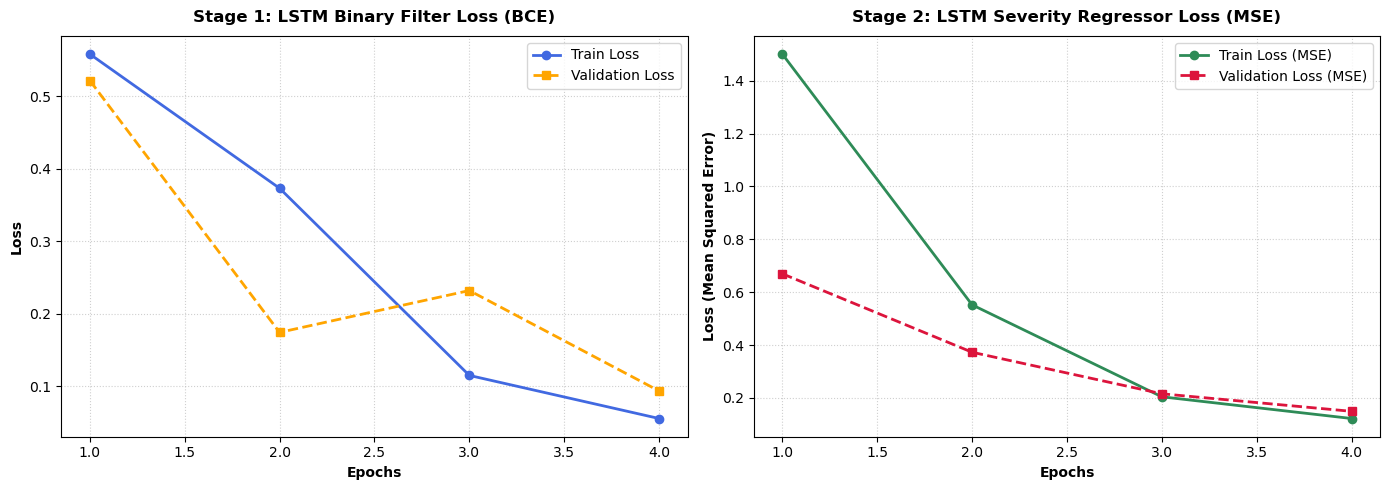

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# gragh part 1
epochs_s1 = range(1, len(history_s1_train) + 1)
ax1.plot(epochs_s1, history_s1_train, 'o-', color='royalblue', label='Train Loss', linewidth=2)
ax1.plot(epochs_s1, history_s1_val, 's--', color='orange', label='Validation Loss', linewidth=2)
ax1.set_title("Stage 1: LSTM Binary Filter Loss (BCE)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Epochs", fontsize=10, fontweight='bold')
ax1.set_ylabel("Loss", fontsize=10, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

# gragh part 2
epochs_s2 = range(1, len(history_s2_train) + 1)
ax2.plot(epochs_s2, history_s2_train, 'o-', color='seagreen', label='Train Loss (MSE)', linewidth=2)
ax2.plot(epochs_s2, history_s2_val, 's--', color='crimson', label='Validation Loss (MSE)', linewidth=2)
ax2.set_title("Stage 2: LSTM Severity Regressor Loss (MSE)", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("Epochs", fontsize=10, fontweight='bold')
ax2.set_ylabel("Loss (Mean Squared Error)", fontsize=10, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("lstm_cascade_learning_curves.png", dpi=300)
plt.show()